# Superstore Sales Analysis & Customer Segmentation
**Goals:** analyze sales and profit trends, find loss-making areas, segment customers with RFM + K-Means, and predict loss-making orders.

**Data:** [Superstore Dataset (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

pd.set_option("display.max_columns", None)

## 2. Load the data

In [2]:
df = pd.read_csv("~/Downloads/Jupyter/Sample - Superstore.csv", encoding="latin-1")
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 3. Explore

In [3]:
df.info()
print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

## 4. Clean the data
If you get a date error, check the date format in `df.head()`. If dates look like 08-11-2016, change the format to `"%d-%m-%Y"`.

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")
df["Postal Code"] = df["Postal Code"].astype(str)   # it's an ID, not a number
df = df.drop(columns=["Row ID", "Country"])          # Row ID is useless, Country is always "United States"
df = df.drop_duplicates()

# New useful columns
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.to_period("M")
df["Ship Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Profit Margin"] = df["Profit"] / df["Sales"]

df.head()

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Ship Days,Profit Margin
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,2016-11,3,0.1600
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,2016-11,3,0.3000
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,2016-06,4,0.4700
3,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,2015-10,7,-0.4000
4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,2015-10,7,0.1125


## 5. Key numbers and YoY growth

In [5]:
print("Total Sales:  ", round(df["Sales"].sum(), 2))
print("Total Profit: ", round(df["Profit"].sum(), 2))
print("Profit Margin:", round(df["Profit"].sum() / df["Sales"].sum() * 100, 1), "%")
print("Orders:       ", df["Order ID"].nunique())
print("Customers:    ", df["Customer ID"].nunique())

yearly = df.groupby("Year")[["Sales", "Profit"]].sum()
yearly["YoY Growth %"] = (yearly["Sales"].pct_change() * 100).round(1)
yearly

Total Sales:   2296919.49
Total Profit:  286409.08
Profit Margin: 12.5 %
Orders:        5009
Customers:     793


,Sales,Profit,YoY Growth %
Year,,,
2014,483966.1261,49556.0329,NaN
2015,470532.5090,61618.6037,-2.8
2016,609205.5980,81795.1743,29.5
2017,733215.2552,93439.2696,20.4


## 6. Monthly sales trend

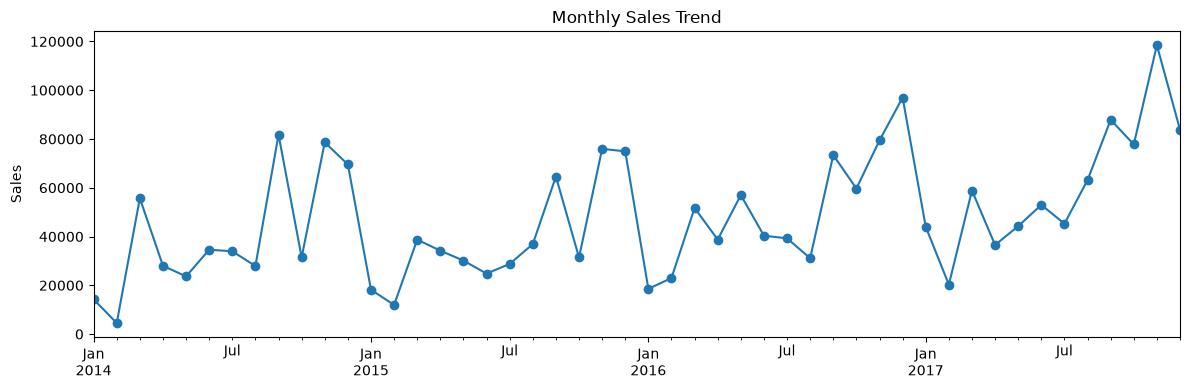

In [6]:
monthly = df.groupby("Month")["Sales"].sum()
monthly.plot(figsize=(12, 4), marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("")
plt.tight_layout()
plt.show()

## 7. Region sales and sub-category profit

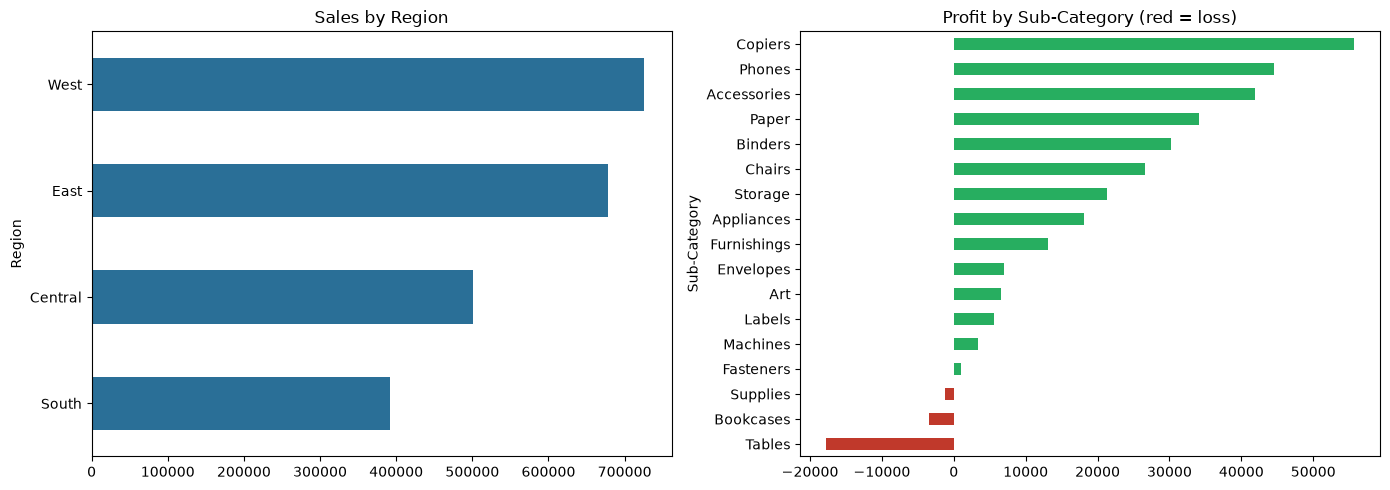

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("Region")["Sales"].sum().sort_values().plot(kind="barh", ax=axes[0], color="#2a6f97")
axes[0].set_title("Sales by Region")

sub = df.groupby("Sub-Category")["Profit"].sum().sort_values()
sub.plot(kind="barh", ax=axes[1], color=["#c0392b" if v < 0 else "#27ae60" for v in sub])
axes[1].set_title("Profit by Sub-Category (red = loss)")

plt.tight_layout()
plt.show()

## 8. Does discount kill profit?

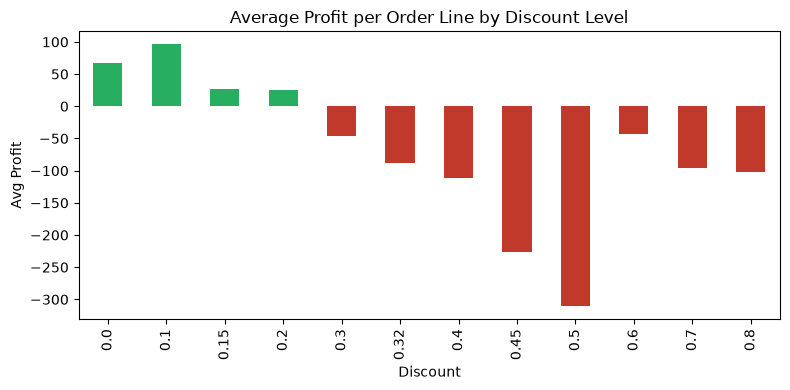

In [8]:
disc = df.groupby("Discount")["Profit"].mean()
disc.plot(kind="bar", figsize=(8, 4), color=["#c0392b" if v < 0 else "#27ae60" for v in disc])
plt.title("Average Profit per Order Line by Discount Level")
plt.ylabel("Avg Profit")
plt.tight_layout()
plt.show()

## 9. RFM table (one row per customer)
- **Recency:** days since last order
- **Frequency:** number of orders
- **Monetary:** total sales

In [9]:
last_date = df["Order Date"].max()

rfm = df.groupby(["Customer ID", "Customer Name"]).agg(
    Recency=("Order Date", lambda x: (last_date - x.max()).days),
    Frequency=("Order ID", "nunique"),
    Monetary=("Sales", "sum"),
).reset_index()

rfm.describe().round(1)

,Recency,Frequency,Monetary
count,793.0,793.0,793.0
mean,146.8,6.3,2896.5
std,186.2,2.6,2628.4
min,0.0,1.0,4.8
25%,30.0,5.0,1146.0
50%,75.0,6.0,2256.4
75%,183.0,8.0,3785.3
max,1165.0,17.0,25043.0


## 10. Scaling + elbow method
K-Means is distance-based, so R, F and M must be on the same scale. `log1p` reduces the pull of a few very large spenders. Pick the k where the line bends (usually 3 or 4).

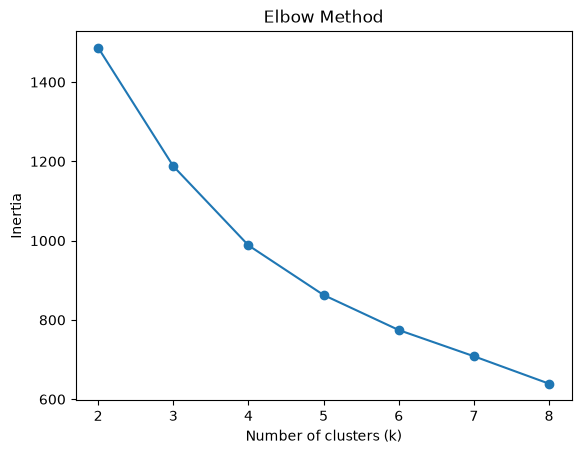

In [10]:
rfm_scaled = StandardScaler().fit_transform(np.log1p(rfm[["Recency", "Frequency", "Monetary"]]))

inertia = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2, 9), inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

## 11. Customer segmentation with K-Means

In [11]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
profile["Customers"] = rfm["Cluster"].value_counts()
profile.sort_values("Monetary", ascending=False)

,Recency,Frequency,Monetary,Customers
Cluster,,,,
2,89.1,8.6,4844.1,259
0,17.2,6.7,2590.0,178
3,228.2,5.1,2032.2,265
1,327.6,2.6,469.5,91


## 12. Name the segments and plot them
Cluster numbers are arbitrary. **Edit the `names` dictionary** to match your profile table: low Recency + high Frequency + high Monetary = Champions; high Recency = At Risk.

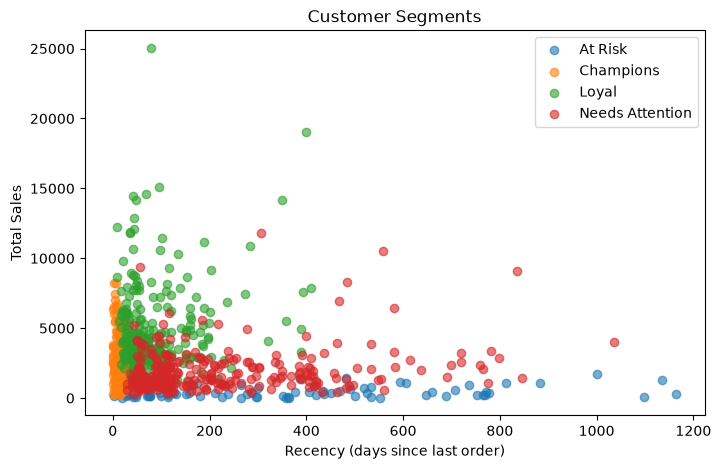

In [12]:
names = {0: "Champions", 1: "At Risk", 2: "Loyal", 3: "Needs Attention"}
rfm["Segment Name"] = rfm["Cluster"].map(names)

plt.figure(figsize=(8, 5))
for name, g in rfm.groupby("Segment Name"):
    plt.scatter(g["Recency"], g["Monetary"], label=name, alpha=0.6)
plt.xlabel("Recency (days since last order)")
plt.ylabel("Total Sales")
plt.title("Customer Segments")
plt.legend()
plt.show()

## 13. Predict loss-making orders (Random Forest)

In [13]:
df["Is Loss"] = (df["Profit"] < 0).astype(int)
print("Share of loss-making order lines:", round(df["Is Loss"].mean() * 100, 1), "%")

features = ["Discount", "Quantity", "Category", "Sub-Category", "Region", "Segment", "Ship Mode"]
X = df[features]
y = df["Is Loss"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_cols = ["Discount", "Quantity"]
cat_cols = ["Category", "Sub-Category", "Region", "Segment", "Ship Mode"]

model = Pipeline([
    ("prep", ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=8,
                                  class_weight="balanced", random_state=42)),
])

model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test), target_names=["Profit", "Loss"]))

Share of loss-making order lines: 18.7 %
              precision    recall  f1-score   support

      Profit       0.97      0.94      0.95      1625
        Loss       0.76      0.88      0.81       374

    accuracy                           0.92      1999
   macro avg       0.86      0.91      0.88      1999
weighted avg       0.93      0.92      0.93      1999



## 14. What drives losses?

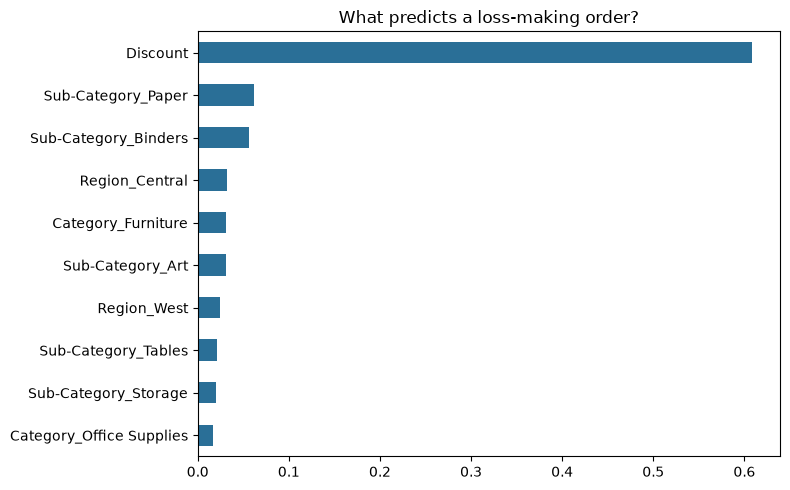

In [14]:
names_out = [n.split("__", 1)[1] for n in model.named_steps["prep"].get_feature_names_out()]
imp = pd.Series(model.named_steps["rf"].feature_importances_, index=names_out).sort_values().tail(10)

imp.plot(kind="barh", figsize=(8, 5), color="#2a6f97")
plt.title("What predicts a loss-making order?")
plt.tight_layout()
plt.show()

## 15. Save outputs
These files can be loaded into Power BI too.

In [15]:
df.to_csv("superstore_clean.csv", index=False)
rfm.to_csv("superstore_customer_segments.csv", index=False)
print("Saved!")

Saved!
